# <center style="font-weight: bold; color: #0098cd;">Procesamiento del lenguaje natural: clasificación y estructuración de datos</center>

## 1. Introducción

### 1.1 Objetivo
transformar texto en datos estructurados útiles para análisis y modelado

👉 siguiente paso: definir **estructura exacta del JSON final + diccionario de normalización LATAM**
Ahí es donde tu TFM pasa de bueno a muy sólido.

### 1.2 Contexto dentro del sistema completo

### 1.3 Requisitos de esta fase

  * clasificación de intención
  * extracción de entidades (NER)
  * normalización

## 2. Preparación del entorno de trabajo

En esta sección se define el entorno técnico necesario para el desarrollo del pipeline de preprocesamiento de audio. Se incluyen la instalación de dependencias, la importación de librerías especializadas y la configuración de rutas de trabajo.

El objetivo es garantizar un entorno reproducible y estructurado que permita ejecutar el flujo completo de procesamiento sobre diferentes conjuntos de datos sin modificaciones en la lógica del código. Asimismo, se establece una organización clara de los directorios que facilita la separación entre datos originales, datos intermedios y resultados finales.

### 2.1 Instalación de dependencias

En este apartado se especifica la instalación de las librerías necesarias para la ejecución del *notebook*. Todas las dependencias se gestionan mediante un archivo `requirements.txt`, lo que permite replicar el entorno de ejecución de forma controlada y consistente.

#### 2.1.1 Configuración del entorno

Este notebook requiere la instalación previa de las dependencias del proyecto.

Ejecutar en terminal:

```bash
pip install -r requirements.txt
python -m spacy download es_core_news_md

### 2.2 Importación de librerías

Se importan las librerías necesarias para las distintas fases del procesamiento, incluyendo manipulación de señal, tratamiento de audio, modelos de detección de voz, análisis de datos y visualización.

Se organiza por bloques funcionales para permitir identificar claramente el propósito de cada conjunto de herramientas dentro del *pipeline*, facilitando la mantenibilidad y comprensión del código.

In [ ]:
# ==============================
# Gestión de rutas y sistema
# ==============================
from pathlib import Path                  # gestión de rutas del sistema de archivos
import json                               # lectura y escritura de ficheros JSON

# ==============================
# Manipulación de datos
# ==============================
import pandas as pd                       # manejo de datos tabulares
import numpy as np                        # operaciones numéricas

# ==============================
# Procesamiento de texto
# ==============================
import re                                 # expresiones regulares
import unicodedata                        # normalización unicode
from unidecode import unidecode           # eliminación de acentos y normalización simplificada

# ==============================
# NLP - modelos y pipelines
# ==============================
import spacy                                           # procesamiento lingüístico y NER
from transformers import AutoTokenizer, AutoModelForSequenceClassification  # modelos tipo BERT (BETO)
from sklearn.preprocessing import LabelEncoder         # codificación de etiquetas para clasificación
from sklearn.model_selection import train_test_split   # partición de datos
from sklearn.linear_model import LogisticRegression    # modelo baseline de clasificación
from sklearn.feature_extraction.text import TfidfVectorizer  # vectorización de texto con TF-IDF
from sklearn.metrics import classification_report, confusion_matrix  # evaluación de modelos

# ==============================
# Normalización y matching
# ==============================
from rapidfuzz import fuzz, process       # comparación difusa de texto (matching de términos)

# ==============================
# Utilidades y control
# ==============================
from tqdm import tqdm                     # barra de progreso
import joblib                             # guardado y carga de modelos


import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import torch
from transformers import Trainer, TrainingArguments, logging
import joblib
import random
from spacy.training.example import Example
from spacy.training import offsets_to_biluo_tags
from spacy.scorer import Scorer
import re
from transformers import set_seed

### 2.3 Gestión y configuración de rutas

In [107]:
# =========================
# DETECCIÓN DE RAÍZ
# =========================

project_root = Path.cwd()

while not (project_root / "data").exists():
    project_root = project_root.parent


# =========================
# DIRECTORIOS
# =========================

# Ruta raíz de datos
data_dir = project_root / "data"


# =========================
# CONFIGURACIÓN
# =========================

# Carpeta de configuración
config_dir = data_dir / "config"

# Subcarpetas de configuración
domain_config_dir = config_dir / "domain"
ner_config_dir = config_dir / "ner"
asr_config_dir = config_dir / "asr"

# Archivos de configuración
domain_terms_path = domain_config_dir / "coffee_cacao_terms.json"
ner_entities_path = ner_config_dir / "ner_entities.json"


# =========================
# DATASETS
# =========================

datasets_dir = data_dir / "datasets"
ner_dataset_dir = datasets_dir / "ner"

# Ruta correcta
ner_dataset_path = ner_dataset_dir / "ner_dataset.json"


# =========================
# TRANSCRIPCIONES (INPUT NLP)
# =========================

transcriptions_dir = data_dir / "transcriptions"

pred_asr_dir = transcriptions_dir / "asr_output"

ground_truth_dir = transcriptions_dir / "ground_truth"


# =========================
# SALIDA NLP
# =========================

structured_data_dir = data_dir / "structured_data"

classification_dir = structured_data_dir / "classification"
ner_dir = structured_data_dir / "ner"
final_output_dir = structured_data_dir / "final_output"


# =========================
# MODELOS NLP
# =========================

models_dir = data_dir / "models"

classification_model_dir = models_dir / "classification_model"
ner_model_dir = models_dir / "ner_model"


# =========================
# CREACIÓN DE CARPETAS
# =========================

# Configuración
domain_config_dir.mkdir(parents=True, exist_ok=True)
ner_config_dir.mkdir(parents=True, exist_ok=True)
asr_config_dir.mkdir(parents=True, exist_ok=True)

# Datasets
ner_dataset_dir.mkdir(parents=True, exist_ok=True)

# Salida NLP
classification_dir.mkdir(parents=True, exist_ok=True)
ner_dir.mkdir(parents=True, exist_ok=True)
final_output_dir.mkdir(parents=True, exist_ok=True)

# Modelos
classification_model_dir.mkdir(parents=True, exist_ok=True)
ner_model_dir.mkdir(parents=True, exist_ok=True)


# =========================
# VERIFICACIÓN
# =========================

print("Ruta raíz:", project_root)

print("\n--- Configuración ---")
print("Dominio:", domain_terms_path)
print("NER:", ner_entities_path)

print("\n--- Datasets ---")
print("NER dataset:", ner_dataset_path)

print("\n--- Input NLP ---")
print("Transcripciones procesadas:", pred_asr_dir)
print("Ground truth:", ground_truth_dir)

print("\n--- Output NLP ---")
print("Clasificación:", classification_dir)
print("NER:", ner_dir)
print("Salida final:", final_output_dir)

print("\n--- Modelos NLP ---")
print("Modelo clasificación:", classification_model_dir)
print("Modelo NER:", ner_model_dir)

Ruta raíz: /Volumes/EXTENSION/GitHub/TFM

--- Configuración ---
Dominio: /Volumes/EXTENSION/GitHub/TFM/data/config/domain/coffee_cacao_terms.json
NER: /Volumes/EXTENSION/GitHub/TFM/data/config/ner/ner_entities.json

--- Datasets ---
NER dataset: /Volumes/EXTENSION/GitHub/TFM/data/datasets/ner/ner_dataset.json

--- Input NLP ---
Transcripciones procesadas: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/asr_output
Ground truth: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/ground_truth

--- Output NLP ---
Clasificación: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/classification
NER: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/ner
Salida final: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/final_output

--- Modelos NLP ---
Modelo clasificación: /Volumes/EXTENSION/GitHub/TFM/data/models/classification_model
Modelo NER: /Volumes/EXTENSION/GitHub/TFM/data/models/ner_model


## 3. Preparación del dataset para NLP

### 3.1 Carga de transcripciones

In [3]:
# -------- ASR --------

# Carga de archivos JSON del ASR
json_paths = sorted(list(pred_asr_dir.glob("*.json")))

dataset_asr = []

for path in json_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        dataset_asr.append({
            "audio_id": data.get("audio_id", path.stem),
            "text": data.get("text", "")
        })
        
    except Exception as e:
        dataset_asr.append({
            "audio_id": path.stem,
            "text": None,
            "error": str(e)
        })

# Conversión a DataFrame
df_asr = pd.DataFrame(dataset_asr)

print(f"ASR cargado: {len(df_asr)} registros")
df_asr.head()


# -------- GROUND TRUTH --------

# Carga de anotaciones manuales
gt_path = ground_truth_dir / "ground_truth.csv"

df_gt = pd.read_csv(gt_path)

print(f"Ground truth cargado: {len(df_gt)} registros")

# Estandarización de columnas para NLP
df_gt = df_gt.rename(columns={
    "transcripcion": "text",
    "clase": "label"
})

df_gt.head()

ASR cargado: 200 registros
Ground truth cargado: 200 registros


,audio_id,text,label
0,AUDIO_00001,"Bueno, hoy estuvimos haciendo deshierbe en el ...",evento_cultivo
1,AUDIO_00002,"Mi nombre es Luis Fernando Taborda, soy produc...",registro_inicial
2,AUDIO_00003,entonces estamos aplicando fertilizante orgáni...,evento_cultivo
3,AUDIO_00004,Ayer estuvimos recogiendo cacao no mucho pero ...,evento_cultivo
4,AUDIO_00005,"Hola, me llamo Carlos Ramírez, soy productor d...",registro_inicial


### 3.2 Normalización de texto para PLN

Se aplica una normalización ligera del texto con el objetivo de reducir la variabilidad superficial asociada a aspectos como la capitalización, la codificación Unicode y la presencia de espacios redundantes. Este proceso permite homogeneizar la representación del texto sin alterar su contenido semántico, preservando así la información lingüística relevante para las tareas de clasificación y reconocimiento de entidades.

### 3.2.1 Función de normalización de texto

In [4]:
def normalize_for_nlp(text):
    
    if text is None:
        return ""
    
    # minúsculas
    text = text.lower()
    
    # normalización unicode (mantiene acentos correctamente)
    text = unicodedata.normalize("NFKC", text)
    
    # eliminación de espacios duplicados
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

### 3.2.2 Aplicación de la normalización al *dataset*

In [5]:
df_asr["text_clean"] = df_asr["text"].apply(normalize_for_nlp)
df_gt["text_clean"] = df_gt["text"].apply(normalize_for_nlp)

### 3.2 Validación de datos

#### 3.2.1 Validación del dataset ASR

In [6]:
# Texto válido: no vacío y tipo string
df_asr["text_valid"] = df_asr["text_clean"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Filtrado
valid_asr = df_asr[df_asr["text_valid"]].copy()
invalid_asr = df_asr[~df_asr["text_valid"]].copy()

print(f"ASR → válidos: {len(valid_asr)}, inválidos: {len(invalid_asr)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_asr) > 0:
    print("\nEjemplos inválidos ASR:")
    display(invalid_asr.head())

ASR → válidos: 200, inválidos: 0


#### 3.2.2 Validación del *dataset Ground Truth*

In [7]:
# Texto válido
df_gt["text_valid"] = df_gt["text_clean"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Label válido (no nulo)
df_gt["label_valid"] = df_gt["label"].notnull()

# Filtrado
valid_gt = df_gt[(df_gt["text_valid"]) & (df_gt["label_valid"])].copy()
invalid_gt = df_gt[~((df_gt["text_valid"]) & (df_gt["label_valid"]))].copy()

print(f"GT → válidos: {len(valid_gt)}, inválidos: {len(invalid_gt)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_gt) > 0:
    print("\nEjemplos inválidos GT:")
    display(invalid_gt.head())

GT → válidos: 200, inválidos: 0


### 3.3 Análisis inicial del *dataset Ground Truth*

In [8]:
print("Distribución de clases:")
print(valid_gt["label"].value_counts())

print("\nDistribución relativa (%):")
print((valid_gt["label"].value_counts(normalize=True) * 100).round(2))

Distribución de clases:
label
evento_cultivo      134
registro_inicial     66
Name: count, dtype: int64

Distribución relativa (%):
label
evento_cultivo      67.0
registro_inicial    33.0
Name: proportion, dtype: float64


La distribución de clases obtenida no se corresponde con el equilibrio inicialmente planteado, observándose un predominio de la clase *evento_cultivo* frente a *registro_inicial*. Esta situación es coherente con la naturaleza de los datos, ya que el registro inicial se realiza una única vez por productor, mientras que los eventos de cultivo se generan de forma recurrente a lo largo del tiempo. Este desbalanceo deberá ser tenido en cuenta en las fases posteriores del proceso de modelado.

## 4. Clasificación de mensajes

### 4.1 Definición de clases a partir del conocimiento del dominio

En este apartado se describen las clases objetivo del problema de clasificación, definidas a partir del conocimiento del dominio y del proceso de etiquetado realizado con apoyo de expertos.

Durante la fase de construcción del dataset, los mensajes fueron anotados manualmente siguiendo criterios establecidos en colaboración con profesionales del ámbito agronómico, quienes identificaron dos tipos principales de información:

- `registro_inicial` mensajes que contienen información descriptiva del productor o de la parcela, utilizados como punto de partida del sistema.
- `evento_cultivo`: mensajes asociados a actividades, incidencias o prácticas agronómicas registradas de forma recurrente en la finca.

Esta categorización refleja la estructura real del flujo de información generado por los productores y permite abordar el problema como una tarea de clasificación binaria alineada con el uso final del sistema.

### 4.2 Preparación del *dataset*

In [56]:
# Mantenemos las columnas necesarias para el modelo: identificador, texto limpio y clase.
df_model = valid_gt[["audio_id", "text_clean", "label"]].copy()

# Codificación de etiquetas
label_encoder = LabelEncoder()
df_model["label_encoded"] = label_encoder.fit_transform(df_model["label"])

# Verificación del tamaño del dataset resultante
print(f"Dataset: {len(df_model)} registros")

# Inspección inicial de los datos
df_model.head()

Dataset: 200 registros


,audio_id,text_clean,label,label_encoded
0,AUDIO_00001,"bueno, hoy estuvimos haciendo deshierbe en el ...",evento_cultivo,0
1,AUDIO_00002,"mi nombre es luis fernando taborda, soy produc...",registro_inicial,1
2,AUDIO_00003,entonces estamos aplicando fertilizante orgáni...,evento_cultivo,0
3,AUDIO_00004,ayer estuvimos recogiendo cacao no mucho pero ...,evento_cultivo,0
4,AUDIO_00005,"hola, me llamo carlos ramírez, soy productor d...",registro_inicial,1


### 4.3 Codificación de etiquetas

In [42]:
# Codificación de etiquetas a valores numéricos para el modelo
label_encoder = LabelEncoder()

df_model["label_encoded"] = label_encoder.fit_transform(df_model["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'evento_cultivo': np.int64(0), 'registro_inicial': np.int64(1)}


### 4.4 División del *dataset* en entrenamiento y test

La división del *dataset* se realiza manteniendo la proporción original de clases mediante una estrategia de partición estratificada. Dado el desbalance existente entre clases, se aplica posteriormente un proceso de balanceo sobre el conjunto de entrenamiento, con el objetivo de mejorar la capacidad del modelo para aprender patrones representativos de ambas clases.

In [43]:
# División del dataset
X = df_model["text_clean"]
y = df_model["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Construcción correcta del DataFrame (alineado)
df_train = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

# Balanceo manual
class_counts = df_train["label"].value_counts()
min_class_size = class_counts.min()

df_class_0 = df_train[df_train["label"] == class_counts.index[0]].sample(n=min_class_size, random_state=42)
df_class_1 = df_train[df_train["label"] == class_counts.index[1]].sample(n=min_class_size, random_state=42)

df_train_balanced = pd.concat([df_class_0, df_class_1]) \
    .sample(frac=1, random_state=42) \
    .reset_index(drop=True)

# Separación final para BETO (formato limpio)
X_train_texts = df_train_balanced["text"].tolist()
y_train_labels = df_train_balanced["label"].tolist()

X_test_texts = X_test.tolist()
y_test_labels = y_test.reset_index(drop=True).tolist()

#### 4.4.1 Análisis de la distribución de clases en entrenamiento y test

In [44]:
print("Distribución TRAIN (balanceado):")
print(pd.Series(y_train_labels).value_counts())
print(pd.Series(y_train_labels).value_counts(normalize=True))

print("\nDistribución TEST (real):")
print(pd.Series(y_test_labels).value_counts())
print(pd.Series(y_test_labels).value_counts(normalize=True))

Distribución TRAIN (balanceado):
1    53
0    53
Name: count, dtype: int64
1    0.5
0    0.5
Name: proportion, dtype: float64

Distribución TEST (real):
0    27
1    13
Name: count, dtype: int64
0    0.675
1    0.325
Name: proportion, dtype: float64


Tras la aplicación del balanceo, el conjunto de entrenamiento presenta una distribución completamente equilibrada entre clases, mientras que el conjunto de test conserva la distribución original del problema, con un predominio de la clase mayoritaria.

Este enfoque permite entrenar el modelo en condiciones controladas, reduciendo el sesgo durante el aprendizaje, y evaluar su rendimiento en un escenario representativo del uso real, donde el desbalance forma parte inherente de los datos.

### 4.5 Modelado

En este apartado se aborda el modelado del problema de clasificación de mensajes a partir del texto transcrito. Para ello, se plantean dos enfoques diferenciados:
- Un modelo *baseline* basado en representaciones clásicas del texto
- Un modelo basado en transformers mediante el uso de BETO.

El modelo *baseline* se construye utilizando una representación TF-IDF de los textos junto con un clasificador de regresión logística. Esta elección responde a su eficacia contrastada en tareas de clasificación de texto, especialmente en escenarios con conjuntos de datos reducidos, donde ofrece un buen equilibrio entre rendimiento, estabilidad y coste computacional. Además, permite establecer una referencia objetiva sobre la que evaluar posteriormente el impacto del uso de modelos más complejos.

A partir de esta base, se incorpora un segundo enfoque basado en BETO, que permite capturar información contextual más rica del lenguaje. La comparación entre ambos enfoques permitirá analizar si el incremento de complejidad se traduce en una mejora real del rendimiento en el contexto del problema planteado.

#### 4.5.1 Modelo baseline (TF-IDF + *Logistic Regression*)

In [45]:
# Vectorización TF-IDF y entrenamiento del modelo baseline
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train_texts)
X_test_tfidf = vectorizer.transform(X_test_texts)

model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train_tfidf, y_train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### 4.5.2 Modelo basado en BETO (*fine-tuning*)

##### 4.5.2.1 Carga del modelo y tokenizer

In [46]:
# Carga de tokenizer y modelo BETO para clasificación
model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model_beto = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

##### 4.5.2.2 Preparación de los datos (tokenización)

In [47]:
# Tokenización de los textos para entrada al modelo
train_encodings = tokenizer(
    X_train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

##### 4.5.2.3 Construcción del *dataset*

In [48]:
# Definición de dataset compatible con PyTorch
class TextDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = TextDataset(train_encodings, y_train_labels)
test_dataset = TextDataset(test_encodings, y_test_labels)

##### 4.5.2.4 Configuración del entrenamiento

In [49]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    save_strategy="no"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


##### 4.5.2.5 Entrenamiento y *Fine-tuning* del modelo BETO

In [50]:
# Inicialización y entrenamiento del modelo
trainer = Trainer(
    model=model_beto,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

/Volumes/EXTENSION/GitHub/TFM/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


TrainOutput(global_step=81, training_loss=0.028485630765373325, metrics={'train_runtime': 55.5377, 'train_samples_per_second': 5.726, 'train_steps_per_second': 1.458, 'total_flos': 20917328901120.0, 'train_loss': 0.028485630765373325, 'epoch': 3.0})

### 4.6 Inferencia sobre el conjunto de test (*ground truth*)

intro aqui

#### 4.6.1 Inferencia con modelo *baseline*

In [51]:
# Predicción sobre el conjunto de test
y_pred = model_baseline.predict(X_test_tfidf)

#### 4.6.2 Inferencia con modelo BETO

In [52]:
# Predicción sobre el conjunto de test utilizando el modelo BETO entrenado
predictions = trainer.predict(test_dataset)

y_pred_beto = predictions.predictions.argmax(axis=1)

### 4.7 Evaluación sobre *ground truth*

#### 4.7.1 Evaluación del modelo *baseline*

,precision,recall,f1-score
evento_cultivo,1.0,1.0,1.0
registro_inicial,1.0,1.0,1.0



Accuracy global: 1.00


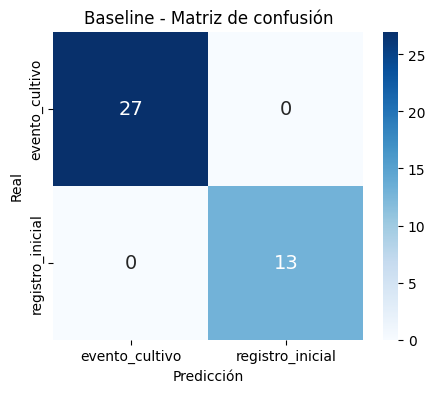

In [53]:
# Reporte como DataFrame (solo métricas por clase)
report_baseline = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics = pd.DataFrame(report_baseline).transpose().iloc[:-3, :-1]
accuracy = report_baseline["accuracy"]

# Visualización tabular
display(df_metrics)
print(f"\nAccuracy global: {accuracy:.2f}")

# Matriz de confusión (baseline - azul)
cm_baseline = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline,
            annot=True,
            fmt="d",
            cmap="Blues",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Baseline - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo *baseline*, basado en representaciones TF-IDF y regresión logística, alcanza valores de rendimiento perfectos en el conjunto de test, evidenciando una capacidad de discriminación completa entre las clases definidas. Este comportamiento se explica por la presencia de patrones lingüísticos claramente diferenciables entre `registro_inicial` y `evento_cultivo`, lo que permite al modelo identificar las clases a partir de la frecuencia de términos sin necesidad de modelado semántico complejo.

#### 4.7.2 Evaluación del modelo BETO

,precision,recall,f1-score
evento_cultivo,1.0,1.0,1.0
registro_inicial,1.0,1.0,1.0


Accuracy global: 1.00


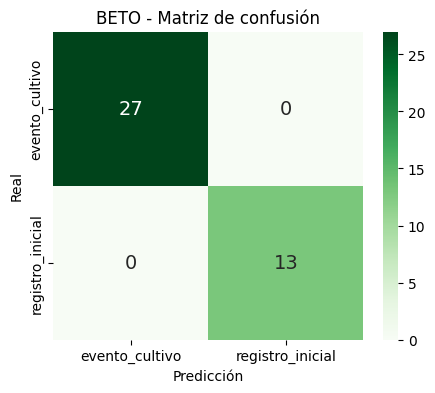

In [54]:
# Evaluación visual del modelo BETO
report_beto = classification_report(
    y_test, y_pred_beto,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_beto = pd.DataFrame(report_beto).transpose().iloc[:-3, :-1]
accuracy_beto = report_beto["accuracy"]

# Visualización tabular
display(df_metrics_beto)
print(f"Accuracy global: {accuracy_beto:.2f}")

# Matriz de confusión (BETO - verde)
cm_beto = confusion_matrix(y_test, y_pred_beto)

plt.figure(figsize=(5,4))
sns.heatmap(cm_beto,
            annot=True,
            fmt="d",
            cmap="Greens",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("BETO - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo basado en BETO presenta igualmente un rendimiento perfecto en el conjunto de test, lo que confirma que el problema es altamente separable en el espacio de representación del lenguaje. Gracias a su capacidad para capturar contexto y relaciones semánticas, el modelo es capaz de modelar el lenguaje de forma más rica; sin embargo, en este escenario concreto, dicha capacidad adicional no se traduce en una mejora observable respecto al modelo *baseline*.

#### 4.7.3 Conclusiones de la evaluación sobre *ground truth*

Los resultados obtenidos en ambos modelos muestran que las clases están definidas por patrones lingüísticos suficientemente evidentes. En particular, los mensajes de tipo `registro_inicial` presentan estructuras descriptivas y estáticas, con presencia frecuente de información personal, ubicaciones y características de la parcela, mientras que los mensajes de `evento_cultivo` contienen referencias a acciones, actividades o incidencias concretas. Esta diferencia genera distribuciones léxicas claramente separadas, lo que facilita la clasificación incluso con modelos simples.

No obstante, estos resultados deben interpretarse con cautela, ya que la evaluación se ha realizado sobre transcripciones manuales (*ground truth*), caracterizadas por una alta calidad lingüística y ausencia de ruido. Estas condiciones favorecen el rendimiento de los modelos y no reflejan completamente el entorno real de aplicación, donde los textos proceden de sistemas ASR y pueden contener errores.

En consecuencia, los resultados obtenidos validan el correcto funcionamiento del *pipeline* en condiciones ideales, pero no permiten extrapolar directamente el rendimiento del sistema en un escenario operativo real, lo que justifica la necesidad de una evaluación posterior utilizando datos generados automáticamente. Asimismo, dado que ambos modelos presentan un rendimiento idéntico en este escenario, no se considera necesario profundizar en el análisis comparativo, al no observarse diferencias significativas entre ellos bajo condiciones ideales.

### 4.8 Evaluación en condiciones reales (ASR)

INTRO AQUI

#### 4.8.1 Preparación de datos ASR

In [ ]:
# Selección de textos ASR
X_asr = df_asr["text_clean"]

# Obtención de etiquetas reales codificadas
y_real = label_encoder.transform(df_gt["label"])

# Conversión a listas
X_asr_texts = X_asr.tolist()
y_real_labels = list(y_real)

200 200


##### 4.8.1.1 Verificación y consistencia del conjunto de datos ASR

In [60]:
# Verificación básica
print(f"Número de textos ASR: {len(X_asr_texts)}")
print(f"Número de etiquetas reales: {len(y_real_labels)}")

# Distribución de clases reales
print("\nDistribución de clases (ASR - etiquetas reales):")
print(pd.Series(y_real_labels).value_counts())
print(pd.Series(y_real_labels).value_counts(normalize=True))

# Verificación de alineación
aligned = (df_asr["audio_id"] == df_gt["audio_id"]).all()
print(f"\n¿Alineación correcta entre ASR y GT?: {aligned}")

if not aligned:
    print(df_asr[["audio_id"]].head())
    print(df_gt[["audio_id"]].head())

Número de textos ASR: 200
Número de etiquetas reales: 200

Distribución de clases (ASR - etiquetas reales):
0    134
1     66
Name: count, dtype: int64
0    0.67
1    0.33
Name: proportion, dtype: float64

¿Alineación correcta entre ASR y GT?: True


La verificación realizada confirma la coherencia del conjunto de datos ASR, observándose una correspondencia exacta entre el número de textos y sus etiquetas asociadas. La distribución de clases mantiene el mismo desbalance que el conjunto original, lo que garantiza que la evaluación se realizará en condiciones representativas del problema real. Asimismo, la alineación correcta entre las transcripciones ASR y el *ground truth* asegura la validez del proceso de evaluación posterior.

##### 4.8.1.2 Transformación de textos ASR para el modelo *baseline*

In [61]:
# Transformación TF-IDF usando el vectorizador entrenado
X_asr_tfidf = vectorizer.transform(X_asr_texts)

##### 4.8.1.3 Preparación de datos ASR para el modelo BETO

In [62]:
# Tokenización de textos ASR
asr_encodings = tokenizer(
    X_asr_texts,
    truncation=True,
    padding=True,
    max_length=128
)

# Dataset PyTorch
asr_dataset = TextDataset(asr_encodings, y_real_labels)

#### 4.8.2 Inferencia sobre datos ASR

In [64]:
# ---------------------------
# Inferencia con modelo baseline
# ---------------------------

# Predicción con TF-IDF + Regresión logística
y_pred_asr_baseline = model_baseline.predict(X_asr_tfidf)


# ---------------------------
# Inferencia con modelo BETO
# ---------------------------

# Predicción con modelo BETO
predictions_asr = trainer.predict(asr_dataset)

# Conversión de logits a clases
y_pred_asr_beto = predictions_asr.predictions.argmax(axis=1)

#### 4.8.3 Evaluación sobre datos ASR

INTRO AQUI

##### 4.8.3.1 Evaluación del modelo *baseline*

,precision,recall,f1-score
evento_cultivo,1.0,1.0,1.0
registro_inicial,1.0,1.0,1.0



Accuracy global (ASR - Baseline): 1.00


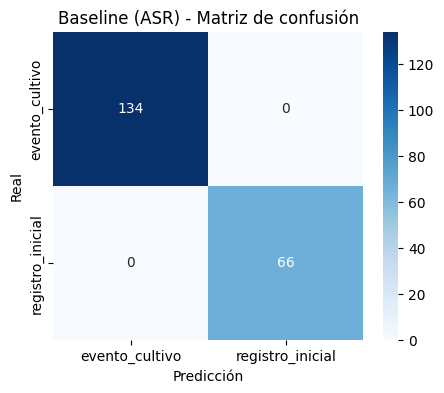

In [65]:
# Reporte baseline ASR
report_asr_baseline = classification_report(
    y_real_labels, y_pred_asr_baseline,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_asr_baseline = pd.DataFrame(report_asr_baseline).transpose().iloc[:-3, :-1]
accuracy_asr_baseline = report_asr_baseline["accuracy"]

display(df_metrics_asr_baseline)
print(f"\nAccuracy global (ASR - Baseline): {accuracy_asr_baseline:.2f}")

# Matriz de confusión
cm_asr_baseline = confusion_matrix(y_real_labels, y_pred_asr_baseline)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_asr_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Baseline (ASR) - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo *baseline* mantiene un rendimiento perfecto sobre los datos ASR, alcanzando valores de precisión, *recall* y F1-score iguales a 1.0 en ambas clases, así como una exactitud global del 100%. Este resultado indica que los errores introducidos por el sistema ASR no afectan a la capacidad del modelo para discriminar entre `evento_cultivo` y `registro_inicial`, manteniéndose la separabilidad observada en el *ground truth*.

##### 4.8.3.2 Evaluación del modelo BETO

,precision,recall,f1-score
evento_cultivo,1.000000,0.992537,0.996255
registro_inicial,0.985075,1.000000,0.992481


Accuracy global (ASR - BETO): 0.99


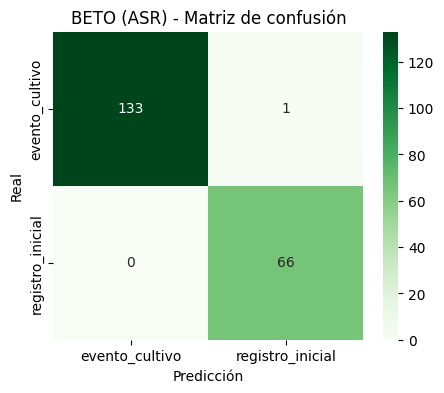

In [66]:
# Reporte BETO ASR
report_asr_beto = classification_report(
    y_real_labels, y_pred_asr_beto,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_asr_beto = pd.DataFrame(report_asr_beto).transpose().iloc[:-3, :-1]
accuracy_asr_beto = report_asr_beto["accuracy"]

display(df_metrics_asr_beto)
print(f"Accuracy global (ASR - BETO): {accuracy_asr_beto:.2f}")

# Matriz de confusión
cm_asr_beto = confusion_matrix(y_real_labels, y_pred_asr_beto)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_asr_beto,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("BETO (ASR) - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo BETO presenta un rendimiento ligeramente inferior, con una exactitud global del 99%. Se observa una leve reducción en el *recall* de la clase `evento_cultivo`, asociada a un único error de clasificación, lo que sugiere una mayor sensibilidad del modelo a pequeñas variaciones introducidas por el ASR. No obstante, el rendimiento general sigue siendo muy elevado, con métricas próximas a la perfección en ambas clases.

#### 4.8.4 Comparación de resultados

Aqui poner lo que realmente se hace en esta seccion:

En este apartado se comparan los resultados obtenidos por el modelo *baseline* y el modelo basado en BETO sobre las transcripciones generadas mediante ASR, con el objetivo de analizar su comportamiento en condiciones más próximas al entorno real.

El análisis se centra en métricas como la exactitud global y el F1-score por clase, así como en la interpretación de las matrices de confusión, lo que permite identificar posibles degradaciones en el rendimiento y errores sistemáticos introducidos por el ASR.

A diferencia de la evaluación sobre ground truth, donde ambos modelos presentaban un comportamiento equivalente, en este escenario se observan ligeras diferencias en el rendimiento, lo que permite analizar con mayor detalle la sensibilidad de cada enfoque ante la variabilidad introducida por el reconocimiento automático del habla.

##### 4.8.4.1 Comparación de F1 por clase

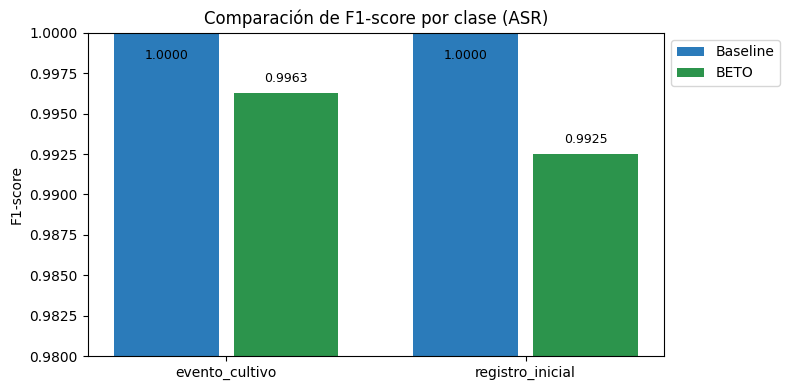

In [75]:
# Clases del problema
classes = list(label_encoder.classes_)

# Extracción de métricas F1 desde los reportes ASR
f1_baseline = [report_asr_baseline[c]["f1-score"] for c in classes]
f1_beto = [report_asr_beto[c]["f1-score"] for c in classes]

# Posiciones en el eje X
x = np.arange(len(classes))
width = 0.35
gap = 0.05

# Colores
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

# Gráfico
plt.figure(figsize=(8,4))

bars1 = plt.bar(x - width/2 - gap/2, f1_baseline, width, label="Baseline", color=color_baseline)
bars2 = plt.bar(x + width/2 + gap/2, f1_beto, width, label="BETO", color=color_beto)

# Configuración
plt.xticks(x, classes)
plt.ylabel("F1-score")
plt.title("Comparación de F1-score por clase (ASR)")

# Zoom en eje Y para ver diferencias pequeñas
plt.ylim(0.98, 1.0)

# Leyenda fuera
plt.legend(loc="upper left", bbox_to_anchor=(1,1))

# Etiquetas sobre las barras (controlando el límite superior)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        
        # Ajuste dinámico de posición
        offset = -0.001 if height > 0.999 else 0.0005
        
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.4f}",
            ha='center',
            va='bottom' if offset > 0 else 'top',
            fontsize=9
        )

plt.tight_layout()
plt.show()

El modelo *baseline* mantiene un rendimiento perfecto en ambas clases, mientras que BETO presenta una ligera degradación, especialmente en `registro_inicial`. Esta diferencia indica que el *baseline* es más robusto frente a los errores introducidos por el ASR en este contexto.

##### 4.8.4.2 Comparación de accuracy

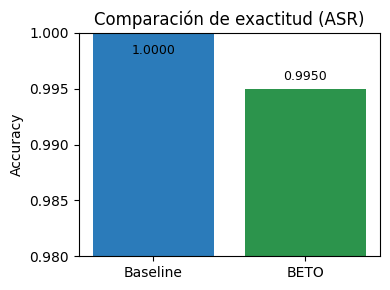

In [81]:
# Extracción de métricas (ASR)
accuracy_baseline = report_asr_baseline["accuracy"]
accuracy_beto = report_asr_beto["accuracy"]

# Colores
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

# Gráfico
plt.figure(figsize=(4,3))

bars = plt.bar(
    ["Baseline", "BETO"],
    [accuracy_baseline, accuracy_beto],
    color=[color_baseline, color_beto]
)

# Zoom para ver diferencias pequeñas
plt.ylim(0.98, 1.0)

# Etiquetas
plt.ylabel("Accuracy")
plt.title("Comparación de exactitud (ASR)")

# Valores encima de barras
for bar in bars:
    height = bar.get_height()
    
    offset = -0.001 if height > 0.999 else 0.0005
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + offset,
        f"{height:.4f}",
        ha='center',
        va='bottom' if offset > 0 else 'top',
        fontsize=9
    )

plt.tight_layout()
plt.show()

La exactitud confirma este comportamiento: el baseline alcanza el 100%, mientras que BETO desciende ligeramente (~99.5%). La diferencia es pequeña, pero consistente con lo observado a nivel de clase.

##### 4.8.4.3 Diferencia de F1

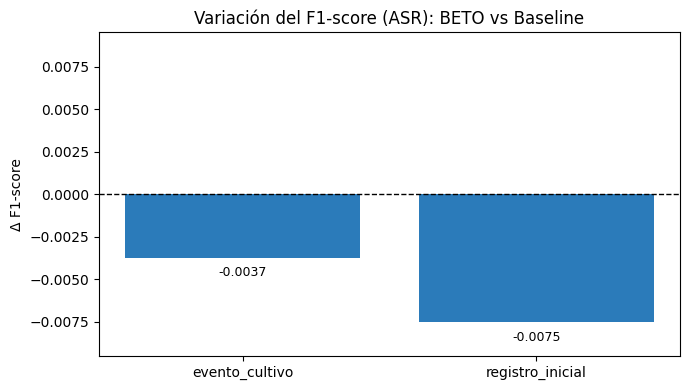

In [79]:
# Diferencia de F1 (BETO - Baseline) en ASR
f1_diff = [b - a for a, b in zip(f1_baseline, f1_beto)]

# Colores
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

colors = [color_beto if v >= 0 else color_baseline for v in f1_diff]

# Gráfico
plt.figure(figsize=(7,4))

bars = plt.bar(classes, f1_diff, color=colors)

# Línea base en 0
plt.axhline(0, color="black", linewidth=1, linestyle="--")

# 🔥 Centrar el 0 en el eje Y
max_abs = max(abs(min(f1_diff)), abs(max(f1_diff)))
plt.ylim(-max_abs - 0.002, max_abs + 0.002)

# Etiquetas
for bar in bars:
    height = bar.get_height()
    
    offset = 0.0005 if height >= 0 else -0.0005
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + offset,
        f"{height:.4f}",
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=9
    )

# Configuración
plt.ylabel("Δ F1-score")
plt.title("Variación del F1-score (ASR): BETO vs Baseline")

plt.tight_layout()
plt.show()

El análisis de la diferencia muestra valores negativos en ambas clases, lo que indica que BETO no mejora al *baseline* en ningún caso. La mayor caída se produce en registro_inicial, lo que sugiere una mayor sensibilidad de este modelo a pequeñas variaciones en el texto.

### 4.9 Análisis final y selección del modelo óptimo

La evaluación del sistema en condiciones más próximas a un entorno real se ha llevado a cabo mediante el uso de transcripciones generadas automáticamente a partir de los mismos audios empleados en la construcción del ground truth. Aunque estas transcripciones introducen errores propios del reconocimiento automático del habla, el contenido semántico de los mensajes se mantiene en gran medida constante.

En este contexto, los resultados obtenidos muestran que ambos modelos presentan un comportamiento altamente satisfactorio, si bien el modelo *baseline* basado en TF-IDF y regresión logística mantiene un rendimiento ligeramente superior. Este comportamiento indica que, para el problema planteado, los patrones lingüísticos que definen cada clase son suficientemente evidentes como para ser capturados mediante representaciones léxicas simples, incluso en presencia de ruido moderado.

La comparación entre ambos enfoques pone de manifiesto que modelos más complejos, como BETO, no siempre garantizan una mejora en el rendimiento cuando el problema es intrínsecamente sencillo o cuando el volumen de datos disponible es limitado. De hecho, en este escenario, el modelo *baseline* demuestra una mayor robustez frente a pequeñas perturbaciones introducidas por el ASR, lo que refuerza la idea de que modelos más simples pueden resultar más adecuados en condiciones de datos restringidos y baja complejidad semántica.

No obstante, estos resultados deben interpretarse con cautela, ya que la evaluación realizada mide principalmente la capacidad de los modelos para mantener el rendimiento ante errores leves de transcripción, pero no permite analizar su comportamiento frente a variaciones más complejas del lenguaje, como ambigüedad, cambios estructurales o expresiones no presentes en el conjunto de entrenamiento.

La limitada disponibilidad de datos condiciona el alcance de los resultados obtenidos, que deben interpretarse como una validación inicial del sistema bajo condiciones controladas. En este contexto, el análisis realizado confirma la capacidad del enfoque propuesto para mantener un alto rendimiento incluso en presencia de errores introducidos por el ASR, si bien no permite extraer conclusiones definitivas sobre su comportamiento en escenarios reales más complejos.

En consecuencia, se selecciona el modelo *baseline* como solución operativa, debido a su elevada exactitud, robustez frente a errores de transcripción y menor complejidad computacional. Por su parte, el modelo BETO se mantiene como una línea de evolución futura, cuya aplicabilidad podría incrementarse en escenarios con mayor volumen de datos, mayor variabilidad lingüística o mayor complejidad semántica, donde su capacidad de modelado contextual pueda aportar un valor diferencial.

Finalmente, como línea de trabajo futura, se plantea la ampliación del conjunto de datos mediante la incorporación de nuevas transcripciones procedentes de nuevos usuarios y contextos, así como la evaluación del sistema en escenarios más exigentes. Este enfoque permitirá analizar con mayor profundidad la capacidad de generalización del modelo.

## 5. Análisis y optimización del modelo BETO

Aunque el modelo *baseline* ha sido seleccionado como solución operativa debido a su rendimiento y robustez en el escenario actual, se incorpora un análisis específico del modelo BETO con el objetivo de evaluar su comportamiento y explorar su potencial en contextos más exigentes.

En este sentido, se plantea un proceso de optimización de sus principales hiperparámetros mediante *fine-tuning*, con el fin de analizar en qué medida un modelo basado en transformers puede mejorar su capacidad de generalización cuando se ajusta adecuadamente. Este análisis no persigue sustituir la solución seleccionada, sino establecer una base experimental que permita valorar la aplicabilidad de este tipo de modelos en futuras iteraciones del sistema.

De este modo, este apartado se orienta a caracterizar el comportamiento de BETO en el contexto del problema planteado, proporcionando una referencia sólida para su posible adopción en escenarios con mayor disponibilidad de datos o mayor complejidad lingüística.

### 5.1 Estrategia de optimización

La optimización del modelo BETO se plantea como un proceso sistemático de evaluación de distintas configuraciones de hiperparámetros durante el *fine-tuning*. Dado que se parte de una arquitectura preentrenada, el objetivo es ajustar su comportamiento mediante parámetros que controlan la dinámica del aprendizaje.

La estrategia adoptada consiste en una búsqueda controlada sobre un conjunto reducido de hiperparámetros clave, seleccionados por su impacto directo en el rendimiento del modelo. En particular, se consideran la tasa de aprendizaje (*learning rate*), el tamaño del lote (*batch size*), el número de épocas (*epochs*) y el parámetro de regularización (*weight decay*).

En lugar de emplear técnicas automatizadas de optimización, se opta por un enfoque de exploración manual mediante la evaluación de combinaciones discretas de valores, lo que permite analizar de forma directa el efecto de cada hiperparámetro sobre el rendimiento del modelo.

Para garantizar la validez de la comparación, todas las configuraciones se evalúan bajo las mismas condiciones, utilizando la misma partición de datos y las mismas métricas definidas previamente. Además, cada experimento parte de una inicialización independiente del modelo, asegurando la comparabilidad de los resultados.

### 5.2 Definición del espacio de búsqueda

In [82]:
# Definimos los hiperparámetros a optimizar en el proceso de fine-tuning

learning_rates = [2e-5, 3e-5, 5e-5]   # Tasa de aprendizaje
batch_sizes = [4, 8]                  # Tamaño de lote
epochs_list = [2, 3, 4]               # Número de épocas
weight_decays = [0.0, 0.01, 0.1]      # Regularización L2

### 5.3 Preparación del conjunto de datos para la optimización

Con el objetivo de garantizar la independencia entre los experimentos realizados en los apartados anteriores y el proceso de optimización, se reconstruye la partición del dataset utilizando la misma semilla aleatoria, asegurando la reproducibilidad de los resultados.

#### 5.3.1 División del dataset en entrenamiento, validación y test

La partición del conjunto de datos se realiza con el objetivo de separar las fases de entrenamiento, validación y evaluación, garantizando una estimación adecuada del rendimiento del modelo. Para ello, se mantiene la distribución de clases original mediante un muestreo estratificado en todos los subconjuntos. Posteriormente, se aplica un proceso de balanceo exclusivamente sobre el conjunto de entrenamiento, con el fin de evitar sesgos durante el aprendizaje, manteniendo los conjuntos de validación y test con su distribución real para evaluar la capacidad de generalización del modelo.

In [87]:
# División inicial
X = df_model["text_clean"]
y = df_model["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# División train → train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# ---------------------------
# Balanceo SOLO en train
# ---------------------------

df_train = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

class_counts = df_train["label"].value_counts()
min_class_size = class_counts.min()

df_class_0 = df_train[df_train["label"] == class_counts.index[0]].sample(n=min_class_size, random_state=42)
df_class_1 = df_train[df_train["label"] == class_counts.index[1]].sample(n=min_class_size, random_state=42)

df_train_balanced = pd.concat([df_class_0, df_class_1]).sample(frac=1, random_state=42).reset_index(drop=True)

#### 5.3.2 Adaptación de los datos al formato requerido por el modelo

In [88]:
# Adaptación a formato texto
X_train_texts = df_train_balanced["text"].tolist()
X_val_texts = X_val.tolist()
X_test_texts = X_test.tolist()

# Labels alineadas
y_train_labels = df_train_balanced["label"]
y_val_labels = y_val.reset_index(drop=True)
y_test_labels = y_test.reset_index(drop=True)

#### 5.3.3 verificación

In [89]:
print("Train balanceado:")
print(pd.Series(y_train_labels).value_counts())

print("\nValidation (real):")
print(y_val.value_counts())

print("\nTest (real):")
print(y_test.value_counts())

Train balanceado:
label
1    42
0    42
Name: count, dtype: int64

Validation (real):
label_encoded
0    21
1    11
Name: count, dtype: int64

Test (real):
label_encoded
0    27
1    13
Name: count, dtype: int64


La distribución obtenida refleja una estrategia de partición adecuada para el entrenamiento y evaluación del modelo. El conjunto de entrenamiento presenta un equilibrio perfecto entre clases, lo que permite evitar sesgos durante el proceso de aprendizaje y favorece la correcta identificación de patrones asociados a cada categoría. Por su parte, los conjuntos de validación y test mantienen la distribución original de los datos, lo que garantiza una evaluación más realista del rendimiento del modelo en condiciones próximas a su uso operativo.

No obstante, el reducido tamaño de los subconjuntos, especialmente en validación, introduce ciertas limitaciones en la estabilidad de las métricas obtenidas. En este sentido, pequeñas variaciones en las predicciones pueden tener un impacto significativo en los resultados, lo que debe tenerse en cuenta a la hora de interpretar el rendimiento del modelo. A pesar de ello, la consistencia en la distribución entre validación y test permite considerar que la evaluación realizada es representativa dentro del contexto y alcance del estudio.

#### 5.3.3 Tokenización de los textos

In [90]:
train_encodings = tokenizer(X_train_texts, truncation=True, padding=True, max_length=128)
val_encodings   = tokenizer(X_val_texts,   truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(X_test_texts,  truncation=True, padding=True, max_length=128)

#### 5.3.4 Construcción de los datasets para entrenamiento

In [91]:
train_dataset = TextDataset(train_encodings, y_train_labels)
val_dataset   = TextDataset(val_encodings,   y_val_labels)
test_dataset  = TextDataset(test_encodings,  y_test_labels)

### 5.3 Evaluación de combinaciones de hiperparámetros

En este apartado se evalua de forma sistemática las distintas combinaciones de hiperparámetros definidas previamente. El objetivo es analizar el impacto de cada configuración sobre el rendimiento del modelo y disponer de una base objetiva para la selección de la alternativa más adecuada.

#### 5.3.1 Control de la reproducibilidad

Con el objetivo de garantizar la consistencia de los resultados obtenidos durante el proceso de optimización, se establece un control explícito de las fuentes de aleatoriedad presentes en el entorno de ejecución. Para ello, se fijan semillas en las principales librerías utilizadas, incluyendo Python, NumPy, PyTorch y HuggingFace, asegurando que cada experimento sea completamente reproducible.

Este enfoque permite evitar variaciones no controladas entre ejecuciones, lo que resulta fundamental para la correcta comparación entre configuraciones de hiperparámetros.

In [98]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    set_seed(seed)

seed_everything(42)

#### 5.3.2 Configuración del entorno experimental

Antes de iniciar el proceso de optimización, se configuran diversos aspectos del entorno de ejecución con el fin de mejorar la legibilidad de los resultados y evitar la aparición de mensajes innecesarios durante el entrenamiento. En particular, se reduce la verbosidad de los logs generados por la librería Transformers y se filtran advertencias específicas relacionadas con el uso de memoria en entornos MPS.

In [99]:
# Inicialización de estructura de resultados
results = []

# Reducción de logs
logging.set_verbosity_error()

# Filtrado de warnings
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*pin_memory.*",
    category=UserWarning
)

#### 5.3.3 Evaluación de combinaciones de hiperparámetros

Para cada configuración, se entrena el modelo desde cero y se evalúa su rendimiento sobre el conjunto de validación, registrando las métricas relevantes para su posterior análisis.

In [100]:
for lr in learning_rates:
    for batch_size in batch_sizes:
        for epochs in epochs_list:
            for wd in weight_decays:

                print(f"\nEntrenando con: lr={lr}, batch={batch_size}, epochs={epochs}, wd={wd}")

                model_beto = AutoModelForSequenceClassification.from_pretrained(
                    model_name,
                    num_labels=len(label_encoder.classes_)
                )

                training_args = TrainingArguments(
                    output_dir="./results",
                    num_train_epochs=epochs,
                    per_device_train_batch_size=batch_size,
                    per_device_eval_batch_size=batch_size,
                    learning_rate=lr,
                    weight_decay=wd,
                    logging_dir="./logs",
                    save_strategy="no",
                    logging_strategy="no",
                    disable_tqdm=False,
                    seed=42
                )

                trainer = Trainer(
                    model=model_beto,
                    args=training_args,
                    train_dataset=train_dataset,
                    eval_dataset=val_dataset
                )

                trainer.train()

                predictions = trainer.predict(val_dataset)
                y_pred = np.argmax(predictions.predictions, axis=1)

                report = classification_report(
                    y_val_labels,
                    y_pred,
                    output_dict=True,
                    zero_division=0
                )

                results.append({
                    "learning_rate": lr,
                    "batch_size": batch_size,
                    "epochs": epochs,
                    "weight_decay": wd,
                    "f1_macro": report["macro avg"]["f1-score"],
                    "accuracy": report["accuracy"],
                    "recall_macro": report["macro avg"]["recall"]
                })


Entrenando con: lr=2e-05, batch=4, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=4, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=2e-05, batch=8, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=4, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=3e-05, batch=8, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=4, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=2, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=3, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=4, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=4, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss



Entrenando con: lr=5e-05, batch=8, epochs=4, wd=0.1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Step,Training Loss


### 5.4 Resultados de la optimización

Se selecciona el *F1-score macro* como métrica principal de evaluación, ya que permite valorar el rendimiento del modelo de forma equilibrada entre las distintas clases, evitando sesgos derivados de posibles desbalances en el conjunto de datos. A diferencia de métricas globales como la exactitud, el *F1-score* integra tanto la *precisión* como el *recall*, proporcionando una medida más robusta del comportamiento del modelo en tareas de clasificación.

Adicionalmente, se registran métricas complementarias como la exactitud y el *recall macro*, con el objetivo de facilitar una interpretación más completa del rendimiento del modelo y analizar posibles desviaciones en su comportamiento.

In [101]:
# Construcción del DataFrame de resultados
df_results = pd.DataFrame(results)

# Ordenación por métrica principal (F1 macro)
df_results_sorted = df_results.sort_values(by="f1_macro", ascending=False)

# Visualización de los mejores resultados
print("Top 5 configuraciones según F1 macro:")
display(df_results_sorted.head())

# Estadísticas globales (opcional pero recomendable)
print("\nResumen de métricas:")
display(df_results.describe())

Top 5 configuraciones según F1 macro:


,learning_rate,batch_size,epochs,weight_decay,f1_macro,accuracy,recall_macro
53,0.00005,8,4,0.10,1.0,1.0,1.0
52,0.00005,8,4,0.01,1.0,1.0,1.0
48,0.00005,8,3,0.00,1.0,1.0,1.0
47,0.00005,8,2,0.10,1.0,1.0,1.0
46,0.00005,8,2,0.01,1.0,1.0,1.0



Resumen de métricas:


,learning_rate,batch_size,epochs,weight_decay,f1_macro,accuracy,recall_macro
count,54.000000,54.00000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.000033,6.00000,3.000000,0.036667,0.971093,0.973380,0.979718
std,0.000013,2.01878,0.824163,0.045391,0.012168,0.011206,0.008538
min,0.000020,4.00000,2.000000,0.000000,0.966066,0.968750,0.976190
25%,0.000020,4.00000,2.000000,0.000000,0.966066,0.968750,0.976190
50%,0.000030,6.00000,3.000000,0.010000,0.966066,0.968750,0.976190
75%,0.000050,8.00000,4.000000,0.100000,0.966066,0.968750,0.976190
max,0.000050,8.00000,4.000000,0.100000,1.000000,1.000000,1.000000


Los resultados obtenidos muestran que varias combinaciones de hiperparámetros alcanzan un rendimiento perfecto (*F1 macro = 1.0*) sobre el conjunto de validación. Este comportamiento indica que el modelo logra capturar completamente la separación entre clases en este contexto. Las configuraciones con mejores resultados se concentran en valores altos de *learning rate* (5e-5) y tamaños de lote mayores (*batch size = 8*), lo que favorece una convergencia rápida sin comprometer la estabilidad del entrenamiento.

A pesar de ello, las diferencias entre configuraciones son mínimas. La mayoría de combinaciones presentan valores de *F1 macro* cercanos a 0.97, con una variabilidad reducida. Este patrón sugiere que el modelo responde de forma muy similar ante cambios en los hiperparámetros dentro del rango analizado, lo que apunta a que el rendimiento está más condicionado por la estructura del dataset que por el ajuste fino del modelo.

La aparición de múltiples configuraciones con métricas perfectas debe analizarse con cautela, pues el tamaño limitado del conjunto de validación implica que pequeñas variaciones en las predicciones pueden modificar las métricas de forma significativa, dificultando la identificación de una configuración claramente superior. En este escenario, la optimización aporta un margen de mejora reducido.

### 5.5 Selección de la configuración óptima

Dado que varias configuraciones alcanzan resultados idénticos en validación, no es posible establecer una jerarquía clara entre ellas en términos de rendimiento. Por este motivo, se selecciona una configuración representativa dentro del conjunto de mejores resultados, atendiendo a criterios de estabilidad y coherencia con el comportamiento observado. En concreto, se elige la combinación `learning rate = 5e-5`, `batch size = 8`, `epochs = 3` y `weight decay = 0.01`, al situarse dentro de las configuraciones con mejor rendimiento y mantener un equilibrio razonable entre convergencia y regularización.

Esta elección está condicionada por las características del *dataset* utilizado. El tamaño reducido y la clara diferenciación entre clases limitan la sensibilidad del modelo a los hiperparámetros. En consecuencia, la configuración seleccionada debe entenderse como válida en este contexto concreto, sin asumir que mantendrá el mismo comportamiento en escenarios con mayor variabilidad o volumen de datos.

### 5.6 Evaluación final del modelo seleccionado

In [102]:
# Configuración seleccionada
best_learning_rate = 5e-5
best_batch_size = 8
best_epochs = 3
best_weight_decay = 0.01

# Modelo desde cero
model_beto_final = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

# Argumentos
training_args_final = TrainingArguments(
    output_dir="./results_final",
    num_train_epochs=best_epochs,
    per_device_train_batch_size=best_batch_size,
    per_device_eval_batch_size=best_batch_size,
    learning_rate=best_learning_rate,
    weight_decay=best_weight_decay,
    save_strategy="no",
    logging_strategy="no",
    seed=42
)

# Trainer
trainer_final = Trainer(
    model=model_beto_final,
    args=training_args_final,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Entrenamiento
trainer_final.train()

# Evaluación en test
predictions_test = trainer_final.predict(test_dataset)
y_pred_test = np.argmax(predictions_test.predictions, axis=1)

# Métricas
report_test = classification_report(
    y_test_labels,
    y_pred_test,
    target_names=label_encoder.classes_,
    digits=4
)

print("Resultados finales en test:")
print(report_test)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'train_runtime': '29.74', 'train_samples_per_second': '8.473', 'train_steps_per_second': '1.11', 'train_loss': '0.0767', 'epoch': '3'}
Resultados finales en test:
                  precision    recall  f1-score   support

  evento_cultivo     1.0000    1.0000    1.0000        27
registro_inicial     1.0000    1.0000    1.0000        13

        accuracy                         1.0000        40
       macro avg     1.0000    1.0000    1.0000        40
    weighted avg     1.0000    1.0000    1.0000        40



La evaluación final sobre el conjunto de test muestra un rendimiento perfecto en todas las métricas consideradas, con valores de precisión, *recall* y *F1-score* iguales a 1.0 para ambas clases. Este resultado confirma que el modelo reproduce correctamente las etiquetas en datos no utilizados durante el entrenamiento ni en la selección de hiperparámetros.

El valor de pérdida obtenido durante el entrenamiento (*train_loss = 0.0767*) indica una convergencia estable, sin señales de inestabilidad en el proceso de aprendizaje. Los tiempos de ejecución son reducidos, coherentes con el tamaño del dataset y la complejidad del problema.

En comparación con los resultados obtenidos en fases anteriores utilizando el modelo sin optimización específica, se observa una ligera mejora en las métricas, especialmente en aquellos casos donde previamente existían pequeñas discrepancias en *recall* y *F1-score*. Esta mejora, aunque marginal, indica que el ajuste de hiperparámetros contribuye a corregir errores puntuales y a estabilizar el comportamiento del modelo.

La mejora observada se produce sobre un conjunto de datos limitado y altamente separable, lo que favorece la obtención de métricas máximas. En este contexto, el incremento de rendimiento no refleja necesariamente una mayor capacidad del modelo para generalizar en escenarios más complejos, sino una optimización sobre un problema ya de por sí sencillo.

## 6. Persistencia del modelo seleccionado para su integración en el sistema

Una vez seleccionado el modelo baseline como solución operativa, se procede a su preparación para su integración en el pipeline de procesamiento. Este proceso implica conservar todos los componentes necesarios para reproducir el flujo completo de inferencia, incluyendo el vectorizador de texto, el modelo de clasificación y el codificador de etiquetas.

### 6.1 Almacenamiento del modelo y sus componentes

In [113]:
# Guardado del vectorizador
joblib.dump(vectorizer, classification_model_dir / "tfidf_vectorizer.pkl")

# Guardado del modelo baseline
joblib.dump(model_baseline, classification_model_dir / "baseline_model.pkl")

# Guardado del codificador de etiquetas
joblib.dump(label_encoder, classification_model_dir / "label_encoder.pkl")

['/Volumes/EXTENSION/GitHub/TFM/data/models/classification_model/label_encoder.pkl']

### 6.2 Comprobación de la integridad del modelo almacenado

In [114]:
try:
    vectorizer_loaded = joblib.load(classification_model_dir / "tfidf_vectorizer.pkl")
    model_loaded = joblib.load(classification_model_dir / "baseline_model.pkl")
    label_encoder_loaded = joblib.load(classification_model_dir / "label_encoder.pkl")

    print("Modelo y componentes cargados correctamente")

except Exception as e:
    print(f"Error al cargar los componentes: {e}")

Modelo y componentes cargados correctamente


## 7. Extracción de entidades (NER)

### 7.1 Validación de la alineación de entidades (*offsets*)

Antes de proceder al entrenamiento del modelo, se realiza una validación del dataset anotado con el objetivo de comprobar la correcta alineación de las entidades definidas mediante offsets.

Este proceso permite detectar errores en los índices de inicio y fin de cada entidad, los cuales deben coincidir exactamente con los límites de los *tokens* generados por spaCy. En caso contrario, dichas entidades serán ignoradas durante el entrenamiento, afectando negativamente al rendimiento del modelo.

Para ello, se emplea la función `offsets_to_biluo_tags`, que permite verificar la correspondencia entre las anotaciones y la tokenización del texto.

<div style="border-left: 5px solid #ff4d4d; padding: 10px; background-color: #2b2b2b; color: #f0f0f0;">
<strong style="color: red">⚠️ Advertencia:</strong> Se recomienda ejecutar este bloque tras cualquier modificación del *dataset* antes de proceder al entrenamiento del modelo.
</div>

In [115]:
# Carga del archivo de entidades NER
with open(ner_dataset_path, "r", encoding="utf-8") as f:
    ner_data_raw = json.load(f)

errores = []

for i, item in enumerate(ner_data_raw):
    text = item["text"]
    entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]

    doc = nlp.make_doc(text)
    tags = offsets_to_biluo_tags(doc, entities)

    if "-" in tags:
        errores.append({
            "index": i,
            "text": text,
            "entities": entities,
            "tags": tags
        })

# Resultado
print(f"Errores encontrados: {len(errores)}")

for e in errores:
    print("\n---")
    print("Index:", e["index"])
    print("Texto:", e["text"])
    print("Entidades:", e["entities"])
    print("Tags:", e["tags"])

NameError: name 'nlp' is not defined

### 6.2 Definición de entidades

In [ ]:
# Carga del archivo de entidades NER
with open(ner_entities_path, "r", encoding="utf-8") as f:
    ner_config = json.load(f)

# Lista de entidades definidas
entities = ner_config["entities"]

# Verificación
print("Entidades definidas para NER:")
print(entities)

### 6.3 Preparación del dataset

In [ ]:
# Ruta correcta
ner_dataset_path = data_dir / "datasets" / "ner" / "ner_dataset.json"

# Carga del dataset
with open(ner_dataset_path, "r", encoding="utf-8") as f:
    ner_data_raw = json.load(f)

# Conversión a formato spaCy
train_data = []

for item in ner_data_raw:
    text = item["text"]
    entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]
    train_data.append((text, {"entities": entities}))

print("Número de ejemplos:", len(train_data))

### 6.4 Implementación del modelo NER

In [ ]:
# Carga modelo base en español
nlp = spacy.load("es_core_news_lg")

### 6.5 Generación de conjuntos *train*/*validation* para evaluación del modelo NER

In [ ]:
# Se divide el dataset en dos subconjuntos (80% entrenamiento, 20% validación)
train_split, val_split = train_test_split(
    train_data,
    test_size=0.2,       
    random_state=42      
)

# Verificación del tamaño de los conjuntos
print("Train:", len(train_split))
print("Validation:", len(val_split))

### 6.6 *Fine-tuning* del modelo NER basado en spaCy

In [ ]:
# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)
spacy.util.fix_random_seed(42)

# Configuraciones de entrenamiento (grid)
results = []

configs = [
    {"n_iter": n, "drop": d}
    for n in [10, 20, 30]
    for d in [0.2, 0.3, 0.4]
]

# Entrenamiento y evaluación de configuraciones
for config in configs:

    print("\nEntrenando config:", config)

    # Carga del modelo base
    nlp = spacy.load("es_core_news_md")
    ner = nlp.get_pipe("ner")

    # Añadir etiquetas del conjunto de entrenamiento
    for _, annotations in train_split:
        for ent in annotations["entities"]:
            ner.add_label(ent[2])

    optimizer = nlp.resume_training()

    # Inicialización del early stopping
    best_loss = float("inf")
    patience = 3
    no_improve = 0
    epochs_run = 0

    # Bucle de entrenamiento
    for epoch in range(config["n_iter"]):

        random.shuffle(train_split)
        losses = {}

        for text, annotations in train_split:
            doc = nlp.make_doc(text)
            example = Example.from_dict(doc, annotations)

            nlp.update(
                [example],
                drop=config["drop"],
                losses=losses
            )

        current_loss = losses.get("ner", 0.0)
        epochs_run += 1

        # Early stopping: mejora del modelo
        if current_loss < best_loss:
            best_loss = current_loss
            no_improve = 0
        else:
            # Early stopping: no mejora acumulada
            no_improve += 1

        # Early stopping: condición de parada
        if no_improve >= patience:
            print("Early stopping activado")
            break

    # Evaluación en conjunto de validación
    scorer = Scorer()
    examples = []

    for text, annotations in val_split:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)

        pred_doc = nlp(text)
        example = Example(pred_doc, example.reference)

        examples.append(example)

    scores = scorer.score(examples)

    # Registro de resultados
    results.append({
        "n_iter": config["n_iter"],
        "drop": config["drop"],
        "epochs_run": epochs_run,
        "loss": best_loss,
        "precision": scores["ents_p"],
        "recall": scores["ents_r"],
        "f1": scores["ents_f"]
    })

    print("F1:", scores["ents_f"])

### 6.7 Análisis de resultados del *fine-tuning*

In [ ]:
# Conversión de los resultados a DataFrame para facilitar su análisis
df_results = pd.DataFrame(results)

# Ordenación de las configuraciones evaluadas:
# - F1 como métrica principal
# - Precision y recall como criterios secundarios
# - Loss como criterio de desempate (menor es mejor)
df_results_sorted = df_results.sort_values(
    by=["f1", "precision", "recall", "loss"],
    ascending=[False, False, False, True]
)

# Visualización de resultados ordenados
display(df_results_sorted)

aqui comentamos y elegimos la mejor

✔️ F1 → métrica principal

✔️ precision → calidad detección

✔️ recall → cobertura

✔️ loss → solo referencia

In [ ]:
plt.scatter(df_results["drop"], df_results["f1"])
plt.xlabel("Dropout")
plt.ylabel("F1")
plt.title("Impacto del dropout en el rendimiento")
plt.show()

In [ ]:
plt.plot(df_results_sorted["f1"].values)

### 6.8 Entrenamiento final del modelo NER tras selección de configuración óptima

In [ ]:
# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)
spacy.util.fix_random_seed(42)

# Selección de la mejor configuración
best_config = df_results_sorted.iloc[0].to_dict()
print("Mejor configuración:", best_config)

# Carga del modelo base
nlp = spacy.load("es_core_news_md")
ner = nlp.get_pipe("ner")

# Añadir etiquetas del dataset completo
for _, annotations in train_data:
    for ent in annotations["entities"]:
        ner.add_label(ent[2])

optimizer = nlp.resume_training()

# Configuración de early stopping
best_loss = float("inf")
patience = 3
no_improve = 0

# Entrenamiento final del modelo
for epoch in range(int(best_config["n_iter"])):

    random.shuffle(train_data)
    losses = {}

    for text, annotations in train_data:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)

        nlp.update(
            [example],
            drop=best_config["drop"],
            losses=losses
        )

    current_loss = losses.get("ner", 0.0)

    print(f"Epoch {epoch+1} - Loss: {current_loss}")

    if current_loss < best_loss:
        best_loss = current_loss
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping activado")
        break

### 6.9 Análisis cualitativo del modelo NER

aqui poner una frase mas complicada

In [ ]:
def extract_entities(text):
    # Normalización ligera del texto antes de aplicar el modelo
    text = normalize_for_nlp(text)
    
    # Procesamiento del texto mediante el modelo NER entrenado
    doc = nlp(text)
    
    # Extracción de entidades detectadas (texto y etiqueta)
    return [(ent.text, ent.label_) for ent in doc.ents]


# Conjunto de ejemplos representativos para análisis cualitativo del modelo
textos = [
    "Ayer al pasarme por el cafetal, me encontré roya en el cafeto y algunas hojas estaban amarillas",
    "La semana pasada estuvimos revisando la parcela y vimos broca en varios granos, pero no aplicamos nada todavía",
    "Después de las lluvias fuertes, apareció monilia en el cacao y se está dañando la mazorca",
    "Fui al lote 3 y noté que el café está en floración pero también hay presencia de ojo de gallo en algunas hojas"
]

# Evaluación del comportamiento del modelo sobre distintos escenarios
for texto in textos:
    print("\nTexto:", texto)
    
    # Aplicación del modelo NER sobre cada ejemplo
    entidades = extract_entities(texto)
    
    # Visualización de entidades detectadas
    print("Entidades detectadas:", entidades)

AQUI COMENTAR QUE HAY COSAS QUE NO DETECTA Y PORQUE Y ASI JUSTIFICAMOS EL USO DEL MODELO HIBRIDO INTEGRANDO DICCIONARIOS.

El análisis cualitativo del modelo permite observar que, si bien es capaz de identificar correctamente ciertas entidades frecuentes como acciones o cultivos, presenta limitaciones en la detección de entidades específicas del dominio agrícola, como plagas o enfermedades (por ejemplo, "roya", "broca" o "monilia").

Este comportamiento es coherente con los resultados obtenidos en la evaluación cuantitativa, donde se observa un valor elevado de precisión pero un recall reducido, lo que indica una detección conservadora de entidades.

Estas limitaciones justifican la necesidad de incorporar mecanismos adicionales que permitan reforzar la detección de términos relevantes del dominio.

### 6.10 Refuerzo mediante conocimiento de dominio (enfoque híbrido)

Explicacion completa: Para evitar la generación de duplicados y posibles inconsistencias en las entidades detectadas, se incorpora un mecanismo de consolidación basado en la priorización de las entidades identificadas por el modelo NER frente a las obtenidas mediante el diccionario de dominio. De este modo, el diccionario actúa únicamente como mecanismo de refuerzo, añadiendo nuevas entidades cuando estas no han sido previamente detectadas por el modelo.

In [ ]:
# Carga del diccionario de dominio
with open(domain_terms_path, "r", encoding="utf-8") as f:
    domain_terms = json.load(f)


# Función de extracción híbrida: modelo NER + diccionario de dominio
def extract_entities_with_domain(text):
    
    # Normalización del texto (clave)
    text = normalize_for_nlp(text)

    # Procesamiento del texto con el modelo NER
    doc = nlp(text)

    # Diccionario para evitar duplicados
    entities_dict = {}

    # Entidades detectadas por el modelo (prioridad)
    for ent in doc.ents:
        key = ent.text.lower()
        entities_dict[key] = ent.label_

    # Texto ya normalizado
    text_lower = text.lower()

    # Refuerzo mediante diccionario de dominio
    for categoria, conceptos in domain_terms.items():
        for concepto, variantes in conceptos.items():
            for variante in variantes:

                # Coincidencia exacta de palabra
                patron = r"\b" + re.escape(variante.lower()) + r"\b"

                if re.search(patron, text_lower):
                    key = variante.lower()

                    # Solo añadir si no existe ya
                    if key not in entities_dict:
                        entities_dict[key] = categoria

    # Convertir a lista
    return [(k, v) for k, v in entities_dict.items()]


# Conjunto de ejemplos representativos para análisis cualitativo del modelo
textos = [
    "Ayer al pasarme por el cafetal, me encontré roya en el cafeto y algunas hojas estaban amarillas",
    "La semana pasada estuvimos revisando la parcela y vimos broca en varios granos, pero no aplicamos nada todavía",
    "Después de las lluvias fuertes, apareció monilia en el cacao y se está dañando la mazorca",
    "Fui al lote 3 y noté que el café está en floración pero también hay presencia de ojo de gallo en algunas hojas"
]

# Evaluación del comportamiento del modelo sobre distintos escenarios
for texto in textos:
    print("\nTexto:", texto)
    
    # Resultado del modelo NER
    entidades = extract_entities(texto)
    print("NER:", entidades)
    
    # Resultado del enfoque híbrido
    print("Híbrido:", extract_entities_with_domain(texto))

### 6.11 Guardado del modelo para integración en *pipeline*

In [ ]:
# Guardado del modelo NER
nlp.to_disk(ner_model_dir)

# Verificación de guardado
print("Modelo NER guardado en:", ner_model_dir)

## 7. Implementación y ejecución del *pipeline* de clasificación y NER

El presente apartado describe la implementación del *pipeline* completo de procesamiento del lenguaje natural, integrando las etapas de clasificación de mensajes y extracción de entidades. El objetivo es transformar el texto transcrito generado por el sistema ASR en una representación estructurada preliminar, identificando tanto la categoría del mensaje como las entidades relevantes presentes en el mismo.

Al igual que en el módulo de transcripción, se adopta un enfoque modular basado en funciones independientes, lo que permite mantener una separación clara de responsabilidades y facilita tanto la validación del sistema como su integración dentro del *pipeline* global.

### 7.1 Inicialización del entorno y gestión de rutas

In [ ]:
# Configuración de rutas del pipeline de clasificación y NER
# Permite localizar automáticamente la estructura del proyecto
# y definir las carpetas de entrada (ASR) y salida (NLP)

def configure_paths(
    base_data_dir: str = "data",
    input_folder: str = "transcriptions/asr_output",
    output_folder: str = "structured_data"
) -> dict:

    project_root = Path.cwd()

    # Detectar raíz del proyecto
    while not (project_root / base_data_dir).exists():
        project_root = project_root.parent

    data_dir = project_root / base_data_dir

    # Carpeta de entrada (salida del ASR)
    input_text_dir = data_dir / input_folder

    # Carpeta base de salida NLP
    structured_data_dir = data_dir / output_folder

    # Subcarpetas específicas
    classification_dir = structured_data_dir / "classification"
    ner_dir = structured_data_dir / "ner"

    # Crear carpetas si no existen
    classification_dir.mkdir(parents=True, exist_ok=True)
    ner_dir.mkdir(parents=True, exist_ok=True)

    return {
        "project_root": project_root,
        "input_text_dir": input_text_dir,
        "classification_dir": classification_dir,
        "ner_dir": ner_dir
    }

### 7.2 Implementación de la función de normalización de texto

In [ ]:
def normalize_for_nlp(text: str) -> str:
    
    if text is None:
        return ""
    
    # Conversión a minúsculas
    text = text.lower()
    
    # Normalización Unicode
    text = unicodedata.normalize("NFKC", text)
    
    # Eliminación de espacios duplicados
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

### 7.3 Implementación de funciones del *pipeline* de clasificación y extracción de entidades

INTRO AQUI

#### 7.2.1 Carga del *dataset* de transcripciones

In [ ]:
# Carga las transcripciones generadas por el ASR
# Devuelve una lista de diccionarios con audio_id y texto

def load_text_dataset(input_text_dir: Path) -> list[dict]:

    json_files = list(input_text_dir.glob("*.json"))

    if len(json_files) == 0:
        raise FileNotFoundError("No se han encontrado transcripciones en el directorio de entrada")

    dataset = []

    for f in json_files:
        with open(f, "r", encoding="utf-8") as file:
            data = json.load(file)

            text_raw = data["text"]

            # Normalización en carga
            text_clean = normalize_for_nlp(text_raw)

            dataset.append({
                "audio_id": data["audio_id"],
                "text": text_raw,
                "text_clean": text_clean
            })

    return dataset

#### 7.2.2 Inicialización de modelos de clasificación y NER

In [ ]:
# Carga los modelos previamente entrenados
# Clasificación (BETO)
# NER (modelo spaCy fine-tuned)

def load_nlp_models(
    classification_model_path: Path,
    ner_model_path: Path
):

    classification_model = joblib.load(classification_model_path)

    nlp = spacy.load(ner_model_path)

    return classification_model, nlp

#### 7.2.3 Clasificación de mensajes

In [ ]:
# Aplica el modelo de clasificación a un texto
# Devuelve la etiqueta predicha

def classify_text(text: str, model) -> str:

    prediction = model.predict([text])[0]

    return prediction

#### 7.2.4 Extracción de entidades (NER)

In [ ]:
# Aplica el modelo NER sobre el texto
# Devuelve lista de entidades detectadas

def extract_entities(text: str, nlp) -> list:

    doc = nlp(text)

    return [(ent.text, ent.label_) for ent in doc.ents]

#### 7.2.5 Refuerzo mediante conocimiento de dominio

In [ ]:
# Refuerza la detección de entidades mediante diccionario de dominio
# Evita duplicados y prioriza las entidades detectadas por el modelo NER

def extract_entities_with_domain(text: str, nlp, domain_terms: dict) -> list:

    doc = nlp(text)

    # Diccionario para evitar duplicados
    entities_dict = {}

    # Entidades detectadas por el modelo (prioridad)
    for ent in doc.ents:
        key = ent.text.lower()
        entities_dict[key] = ent.label_

    # Conversión a minúsculas
    text_lower = text.lower()

    # Refuerzo mediante diccionario de dominio
    for categoria, conceptos in domain_terms.items():
        for concepto, variantes in conceptos.items():
            for variante in variantes:

                # Escapamos caracteres especiales y buscamos palabra completa
                patron = r"\b" + re.escape(variante.lower()) + r"\b"

                if re.search(patron, text_lower):

                    key = variante.lower()

                    # Solo añadir si no existe ya
                    if key not in entities_dict:
                        entities_dict[key] = categoria

    # Convertir a lista de tuplas
    return [(k, v) for k, v in entities_dict.items()]

#### 7.2.6 Generación de salida estructurada preliminar

In [ ]:
# Genera estructura final del pipeline NLP (sin normalización)

def process_text(
    item: dict,
    classification_model,
    nlp,
    domain_terms
) -> dict:

    text_clean = item["text_clean"]

    label = classify_text(text_clean, classification_model)

    entities = extract_entities_with_domain(text_clean, nlp, domain_terms)

    return {
        "audio_id": item["audio_id"],
        "text": item["text"],          # raw
        "text_clean": text_clean,      # limpio
        "label": label,
        "entities": entities
    }

### 7.3 Ejecución del *pipeline* de clasificación y NER

In [ ]:
print("Inicializando pipeline NLP...")

# Configuración de rutas
paths = configure_paths()
print("Rutas configuradas correctamente")

# Carga de transcripciones
print("Cargando dataset de transcripciones...")
text_dataset = load_text_dataset(paths["input_text_dir"])
print(f"Registros cargados: {len(text_dataset)}")

# Carga de modelos
print("Cargando modelos NLP...")
classification_model_path = models_dir / "classification_model"
ner_model_path = models_dir / "ner_model"

classification_model, nlp = load_nlp_models(
    classification_model_path,
    ner_model_path
)
print("Modelos cargados correctamente")

# Carga del diccionario de dominio
print("Cargando diccionario de dominio...")
with open(domain_terms_path, "r", encoding="utf-8") as f:
    domain_terms = json.load(f)
print("Diccionario cargado correctamente")

# Procesamiento del dataset
print("Procesando textos...")
results = []

for item in text_dataset:
    processed = process_text(
        item,
        classification_model,
        nlp,
        domain_terms
    )
    results.append(processed)

print(f"Registros procesados: {len(results)}")

# Guardado de resultados
print("Guardando resultados...")

for item in results:

    # Guardado clasificación
    output_classification_path = paths["classification_dir"] / f"{item['audio_id']}.json"

    with open(output_classification_path, "w", encoding="utf-8") as f:
        json.dump({
            "audio_id": item["audio_id"],
            "text": item["text"],
            "text_clean": item["text_clean"],
            "label": item["label"]
        }, f, ensure_ascii=False, indent=4)

    # Guardado NER
    output_ner_path = paths["ner_dir"] / f"{item['audio_id']}.json"

    with open(output_ner_path, "w", encoding="utf-8") as f:
        json.dump({
            "audio_id": item["audio_id"],
            "entities": item["entities"]
        }, f, ensure_ascii=False, indent=4)

print("Resultados guardados correctamente")

print("Pipeline NLP completado correctamente")

### 7.4 Validación del *pipeline* de clasificación y NER

In [ ]:
print("Iniciando validación del pipeline NLP...")

# Verificación de conteo
assert len(results) == len(text_dataset), "Error: número de resultados no coincide"
print("✔ Conteo correcto")

# Verificación de estructura y contenido
audio_ids = set()

for item in results:

    # Campos obligatorios
    assert "audio_id" in item, "Error: falta 'audio_id'"
    assert "text" in item, "Error: falta 'text'"
    assert "text_clean" in item, "Error: falta 'text_clean'"
    assert "label" in item, "Error: falta 'label'"
    assert "entities" in item, "Error: falta 'entities'"

    # Tipos
    assert isinstance(item["text"], str), "Error: 'text' no es string"
    assert isinstance(item["text_clean"], str), "Error: 'text_clean' no es string"
    assert isinstance(item["label"], str), "Error: 'label' no es string"
    assert isinstance(item["entities"], list), "Error: 'entities' no es lista"

    # Contenido
    assert item["text"].strip() != "", f"Texto vacío en {item['audio_id']}"
    assert item["text_clean"].strip() != "", f"Texto limpio vacío en {item['audio_id']}"

    # Unicidad
    assert item["audio_id"] not in audio_ids, f"audio_id duplicado: {item['audio_id']}"
    audio_ids.add(item["audio_id"])

print("✔ Estructura y contenido correctos")
print("✔ Unicidad de audio_id verificada")

# Verificación básica de entidades
for item in results:
    for ent in item["entities"]:
        assert isinstance(ent, tuple), "Entidad mal formada (no es tupla)"
        assert len(ent) == 2, "Entidad mal formada (estructura incorrecta)"

print("✔ Formato de entidades correcto")

# Muestra para inspección manual
print("\n=== Muestra de resultados NLP ===")
sample = pd.DataFrame(results).sample(n=min(5, len(results)), random_state=42)
display(sample)

print("Validación completada correctamente")

## 8. Conclusiones